# __Phase 1: Data Exploration and Preparation__

In [2]:
import pandas  as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import StrMethodFormatter, FuncFormatter

In [3]:
# see all columns
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)  

#### __Accessible data:__
From foodforecast we have four data scources as .parquet files:
1) __Sales__: Containig sales data from Qtr 2 2025
2) __Stores__: Containing Store Metadata (Id, zipcode, weekly revenue mean Qtr 1 2025)
3) __Holidays__: Containing a list of holidays dates in and in the corresponding region
3) __weather__: Containnig weather data form the corresponding regions and time span.   

#### __Objective:__
1) __The overall objective__ ist to predict the sold_quantity of items for the next day and enrich existing features with publicly available data to optimize the predictions. This is a __regression__ issue.
2) __for this notebook:__ Understanding, cleaning the four data sources to have one single dataframe ready for modeling.

# __Data exploration and data cleaning__

## __Data: Sales__ 


In [4]:
# loading data
sales = pd.read_parquet('20260218_144523_sales_data.parquet', engine='pyarrow')
#sales = pd.read_parquet('20260218_144523_sales_data.parquet', engine='fastparquet')
display(sales.head())


,date,category_name,item_id,sold_quantity,price,store_id
0,2025-04-01,Angebot Brötchen,139,15.0,0.0,0
1,2025-04-01,Angebot Feinbäckerei,138,28.0,0.0,0
2,2025-04-01,Angebot Heißgetränke,106,25.0,0.0,0
3,2025-04-01,Angebot Heißgetränke,539,5.0,1.4,0
4,2025-04-01,Angebot Snack,176,1.0,0.0,0


### Data Structure



This table contains bakery sales data per day from one client with several stores of the federal district of germany (NRW; northrhine westphalia) in the 2nd quarter of 2025 (1. Apr-30. Jun).

__Variables:__

> __date:__ the day of sales [datetime64[ns]]

> __category_name:__ name of the item category in german [str]

> __item_id__: the unique item id [int64]

> __sold_quantity__: the sales amount of the item per day ---> (this is the __target__ variable) [float64]

> __price__: the item's price [float64]

> __store_id__: unique id of one store [int64]


### Overview

In [ ]:

# shape
print('Shape sales:', sales.shape, end='\n\n')

# info
print(sales.info())

# decription numeric and categorical
display(sales.describe())
display(sales.describe(include='str'))



Shape sales: (713637, 6)

<class 'pandas.DataFrame'>
RangeIndex: 713637 entries, 0 to 713636
Data columns (total 6 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   date           713637 non-null  datetime64[ns]
 1   category_name  713637 non-null  str           
 2   item_id        713637 non-null  int64         
 3   sold_quantity  713637 non-null  float64       
 4   price          696648 non-null  float64       
 5   store_id       713637 non-null  int64         
dtypes: datetime64[ns](1), float64(2), int64(2), str(1)
memory usage: 38.8 MB
None


,date,item_id,sold_quantity,price,store_id
count,713637,713637.000000,713637.000000,696648.000000,713637.000000
mean,2025-05-15 16:04:01.050282240,262.957623,15.845915,2.747405,30.802189
min,2025-04-01 00:00:00,0.000000,-1.000000,-22.000000,0.000000
25%,2025-04-24 00:00:00,67.000000,1.000000,1.100000,14.000000
50%,2025-05-16 00:00:00,220.000000,4.000000,2.600000,30.000000
75%,2025-06-07 00:00:00,449.000000,12.000000,3.800000,46.000000
max,2025-06-30 00:00:00,676.000000,2425.000000,115.000000,83.000000
std,NaN,216.843557,60.843418,2.129056,19.148652


,category_name
count,713637
unique,23
top,Brötchen
freq,195190


In [6]:
# Analyse the distribution of categorical variable
sales['category_name'].value_counts()

category_name
Brötchen                195190
Brot                    150172
Snack                    75142
Kaltgetränke 19%         61263
Kuchen                   61095
Heißgetränke             48316
Feinbäckerei             46475
Snack Belag              22334
Konditorei               14304
Angebot Brötchen         11529
Angebot Feinbäckerei      6179
Kaltgetränke 7%           5845
Printen/Kekse             5078
Angebot Heißgetränke      4623
Eigerichte                3241
Angebot Brot               974
Gastro Gerichte            929
Angebot Snack              670
Frühstücke                 113
Printen Waage               98
Angebot Kuchen              65
Brotwaage                    1
Angebot Gastro               1
Name: count, dtype: int64

#### Observations

* the max. price is very high
* the max. quantity is also very high
* missing values in price (~2%)
* negative prices
* negative quantities
* there is only one line each for Brotwaage and Angebot Gastro


### Data Cleaning

In [7]:
#checks 

# any duplicated rows?
print('Duplicates in sales:', sales.duplicated().sum())

# any missing values?
missing = sales.isna().sum()
print('\nMissing values:')
print(missing)



Duplicates in sales: 0

Missing values:
date                 0
category_name        0
item_id              0
sold_quantity        0
price            16989
store_id             0
dtype: int64


In [ ]:
##!!
# --> Missing values only in price

# but price has also 0 and negative values - why? promotion? discount?
price_gt_0 = sales[sales.price > 0].shape[0]
price_lte_0 = sales[sales.price <= 0].shape[0]

# all rows 
all_price = sales.price.count()

# percent less than or equal to 0
perc_lte_0 = price_lte_0 / all_price * 100

# calculate proportion of price =< 0
print('Price > 0 \t ->', price_gt_0)
print('Price <= 0 \t ->', price_lte_0, f'({perc_lte_0:.1f} %)')
print(f'{perc_lte_0:.1f} % of price column are 0 or below (2759 (0.4 %) rows below 0)')


##!! price == NaN -> sold_quantity always 0 --> can we delete price NaN rows, since you cannnot sell anything w/out a price

# price is not our target, so i would leave the rows in dataframe and replace missing values with 0
#sales['price'] = sales.price.fillna(0)

# removing NA in price
sales = sales.dropna(subset=['price'])
#display(sales.isna().sum())

# no more missing values
print('\nNo more missing values in sales:')
display(sales.isna().sum())

Price > 0 	 -> 645628
Price <= 0 	 -> 51020 (7.3 %)
7.3 % of price column are 0 or below (2759 (0.4 %) rows below 0)

No more missing values in sales:


date             0
category_name    0
item_id          0
sold_quantity    0
price            0
store_id         0
dtype: int64

### Target outliers 

 - TARGET description - 
count    713637.000000
mean         15.845915
std          60.843418
min          -1.000000
25%           1.000000
50%           4.000000
75%          12.000000
max        2425.000000
Name: sold_quantity, dtype: float64

Whiskers factor: 1.5

Values high threshold: 28.5
Values low threshold: -15.5


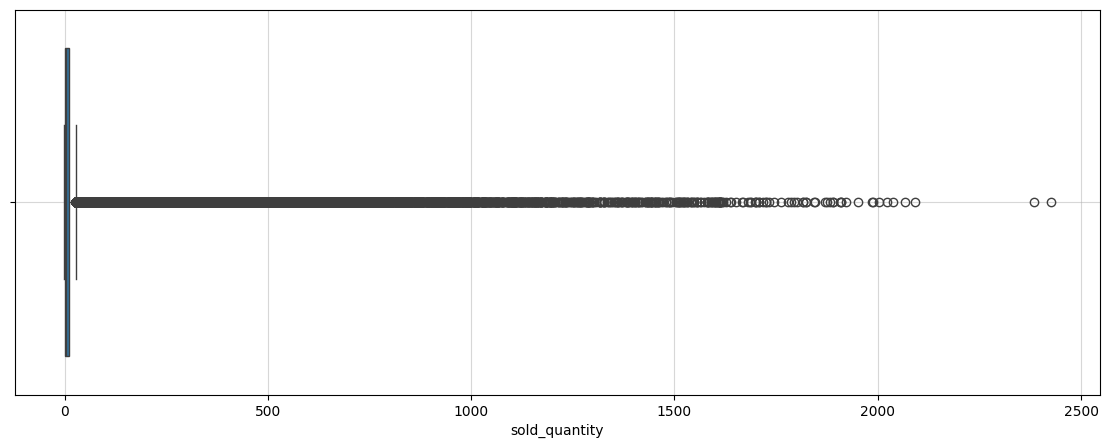

------------------------------------------------------------

- TARGET inconsistncies-
sold_quantity  > 0 	 -> 607502
sold_quantity <= 0 	 -> 106135 (14.9 %)

14.9 % of target column are 0 or below (2 rows only below 0 and can be neglected)
How to deal with sold_quantity = 0?
------------------------------------------------------------
Count of outliers 72529 (10.16 %).
Conclusion: Outliers seem to be significant and should not be erased.


In [9]:
# investigating target
print(' - TARGET description - ')
print(sales.sold_quantity.describe())

# -------- Outliers ----------

# boxplot and IQR

# IQR

# calculating quantiles
q1, q2, q3 = sales.sold_quantity.quantile([0.25, 0.5, 0.75])

# inter quartile range
IQR = q3 - q1

whiskers = 1.5

# outliers border
extreme_high = q3 + IQR * whiskers
extreme_low = q1 - IQR * whiskers

print('\nWhiskers factor:', whiskers)
print('\nValues high threshold:', extreme_high)
print('Values low threshold:', extreme_low)

# boxplot
plt.figure(figsize=(14,5))
sns.boxplot(x=sales.sold_quantity, whis=whiskers)
plt.grid(True, 'both', alpha=0.5)
plt.show()


# ----- questions and inconsistncies -------

# target values < 0 
sold_qty_gt_0 = sales[sales.sold_quantity > 0].shape[0]
sold_qty_lte_0 = sales[sales.sold_quantity <= 0].shape[0]

# all rows 
all_sold = sales.sold_quantity.count()

# percent less than or equal to 0
perc_lte_0 = sold_qty_lte_0 / all_sold * 100
 
print('-'*60)
print('\n- TARGET inconsistncies-')
print('sold_quantity  > 0 \t ->', sold_qty_gt_0)
print('sold_quantity <= 0 \t ->', sold_qty_lte_0, f'({perc_lte_0:.1f} %)')
print(f'\n{perc_lte_0:.1f} % of target column are 0 or below (2 rows only below 0 and can be neglected)')
print('How to deal with sold_quantity = 0?')

# ...
# count of outliers
outlier_cond = (sales.sold_quantity > extreme_high) | (sales.sold_quantity < extreme_low)
outliers = sales[outlier_cond].sort_values('sold_quantity', ascending=False)
outliers_count = outliers.shape[0]

# percent
perc_outliers = outliers_count / len(sales.sold_quantity) * 100

print('-'*60)
print(f'Count of outliers {outliers_count} ({perc_outliers:.2f} %).' )

# conclusion
print('Conclusion: Outliers seem to be significant and should not be erased.')

### __Investigating__

In [10]:
# strange
# there a items sold without a price but sold qty > 0

strange_solds_cond = (sales.sold_quantity != 0) & (sales.price == 0)

strange_solds = sales[strange_solds_cond] # -> more than 40,000 rows have sold items but no price. since our target it quantity sold, i would leave this untouched
display(strange_solds.sample(8))

strange_solds_count = strange_solds.shape[0]

perc_strange_solds = strange_solds_count / len(sales.sold_quantity) * 100

print(f'Count of items sold with price eq to 0: {strange_solds_count} ({perc_strange_solds:.2f} %).' )
print('\nHow do we deal with those occurences in price and sold_quantity?')
print('Assumption: These are results of promotion (buy one, get two, etc.) or give-a-ways (give away for free short before closing time) , so it \nseems reasonable that there are items giving away for free, i.e. without price.')

,date,category_name,item_id,sold_quantity,price,store_id
239997,2025-05-02,Angebot Heißgetränke,106,4.0,0.0,21
648602,2025-06-23,Angebot Brötchen,139,15.0,0.0,2
405460,2025-05-21,Feinbäckerei,203,9.0,0.0,83
531533,2025-06-06,Angebot Brötchen,139,13.0,0.0,50
610743,2025-06-17,Angebot Brötchen,46,17.0,0.0,30
583474,2025-06-13,Brötchen,43,13.0,0.0,72
373422,2025-05-17,Feinbäckerei,220,7.0,0.0,76
86149,2025-04-10,Brötchen,43,20.0,0.0,76


Count of items sold with price eq to 0: 41824 (5.86 %).

How do we deal with those occurences in price and sold_quantity?
Assumption: These are results of promotion (buy one, get two, etc.) or give-a-ways (give away for free short before closing time) , so it 
seems reasonable that there are items giving away for free, i.e. without price.


### Prepare for visualization and merging

In [ ]:
# enrich dates for better analysis and visuaiisation
sales['month'] = sales.date.dt.month
sales['day_of_week'] = sales.date.dt.day_of_week
sales['week'] = sales.date.dt.isocalendar().week
# sales['day'] = sales.date.dt.day_name()  # -> not needed, too much RAM
sales.head()

## __Data: Stores__ 


In [27]:
# loading stores

stores = pd.read_parquet('20260218_144523_stores.parquet', engine='pyarrow')
stores.head()


,subdivision_code,country_code,zipcode,average_weekly_revenue_Q1,store_id
0,DE-NW,DE,52062,21448.248159,0
1,DE-NW,DE,52224,17844.961211,1
2,DE-NW,DE,52134,12808.989643,2
3,DE-NW,DE,52062,7635.616974,3
4,DE-NW,DE,52222,21000.922881,4


### Data Structure

This table contains store meta data of __serveral stores__ belonging to __one client__. 

__Variables:__

> __subdivision_code:__ The abbreviation for the federal state in Germany [str, categorical]

> __country_code__: The code of the country [str, categorical]

> __zipcode__: The postal code of the area where the store is located [int64, categorical]

> __average_weekly_revenue_Q1__: The average weekly revenue per store from Qtr 1 2025 (we have sales data form Qtr2) [float64, quantitative]

> __store_id__: The unique Id of a store [float64, categorical]

> 


### Overview

In [28]:
# overview

# shape
print('Shape stores:', stores.shape, end='\n\n')

# info
print(stores.info())

# decription numeric and categorical
display(stores.describe())
display(stores.describe(include='str'))

Shape stores: (84, 5)

<class 'pandas.DataFrame'>
RangeIndex: 84 entries, 0 to 83
Data columns (total 5 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   subdivision_code           84 non-null     str    
 1   country_code               84 non-null     str    
 2   zipcode                    84 non-null     str    
 3   average_weekly_revenue_Q1  84 non-null     float64
 4   store_id                   84 non-null     int64  
dtypes: float64(1), int64(1), str(3)
memory usage: 4.4 KB
None


,average_weekly_revenue_Q1,store_id
count,84.000000,84.000000
mean,13474.966931,41.500000
std,10001.293301,24.392622
min,0.000000,0.000000
25%,0.000000,20.750000
50%,15077.306829,41.500000
75%,20770.518048,62.250000
max,35944.005291,83.000000


,subdivision_code,country_code,zipcode
count,84,84,84
unique,1,1,36
top,DE-NW,DE,52064
freq,84,84,5


### Data Cleaning

In [29]:
## duplicates?
print('Dublicates in store:', stores.duplicated().sum())

# missing values
print('\nMissing values:')
print(stores.isna().sum())



Dublicates in store: 0

Missing values:
subdivision_code             0
country_code                 0
zipcode                      0
average_weekly_revenue_Q1    0
store_id                     0
dtype: int64


In [ ]:
# deleting constant variables

print('Since the variables country_code and subdivision_code contain only ONE constant value, they do not provide any \
\nadditional information and can be deleted.')

stores = stores.drop(columns=['subdivision_code', 'country_code'], errors='ignore')

# check
display(stores.head())


Since the variables country_code and subdivision_code contain only ONE constant value, they do not provide any 
additional information and can be deleted.


,zipcode,average_weekly_revenue_Q1,store_id
0,52062,21448.248159,0
1,52224,17844.961211,1
2,52134,12808.989643,2
3,52062,7635.616974,3
4,52222,21000.922881,4


In [ ]:
##!!
# -> investigating stores with average_weekly_revenue_Q1 == 0

# because of the description above the values of average_weekly_revenue_Q1 below the first (quartile, 25%) are 0.

#cond = stores.average_weekly_revenue_Q1 == 0
#stores[cond]

#xx = stores.groupby(['zipcode', 'store_id'])['average_weekly_revenue_Q1'].apply(lambda x: set(list(x)))
#pd.DataFrame(xx)

# sales with store_id > 60 
#sales_60 = (sales.store_id >= 59) #& (sales.sold_quantity > 0) #& 
#sales[sales_60].groupby(['store_id', 'category_name'])['item_id'].apply(lambda x: sorted(set(x)))

#display(sales[sales_60].describe())
#display(sales[sales_60].describe(include='str'))
#sales[sales_60].boxplot()

### __Investigating__

In [32]:
# revenue qtr2 vs. qtr1


# creating a new column sales to calculate the revenue of Qtr 2
sales['revenue'] = sales.price * sales.sold_quantity
#display(sales.sort_values('revenue', ascending=False))

# creating revenue per store and per week for Qtr 2
rev_q2_week = pd.DataFrame(sales.groupby(['store_id', 'week'])['revenue'].sum())
rev_q2_week.sort_values('revenue', ascending=False)

# creating avgeage of weekly revenue Qtr 2
average_weekly_revenue_Q2 = rev_q2_week.groupby('store_id')['revenue'].mean()

# putting result in a dataframe and renaming the column
average_weekly_revenue_Q2 = pd.DataFrame(average_weekly_revenue_Q2).rename(columns={'revenue':'average_weekly_revenue_Q2'})

#display(average_weekly_revenue_Q2.sort_values('average_weekly_revenue_Q2', ascending=False).head(10))

#display(stores_revQ1.head(10))


# concat rev q2 to stores
# merge revenue vaiable for Qtr 2 and storr df (with revenue Qtr 1) into new df
stores_rev = pd.merge(left=stores, right=average_weekly_revenue_Q2, on='store_id')
display(stores_rev.sort_values('store_id').tail(28))

print('Result: It seems that stores with id >= 60 have no revenue in Qtr1 or Qtr 2.')



KeyError: 'week'

In [ ]:
# visulizing the result

# melting avg weekly columns for plotting
stores_rev = stores_rev.melt(id_vars='store_id', value_vars=['average_weekly_revenue_Q1', 'average_weekly_revenue_Q2'], var_name='Qtr', value_name='avg_weekly_rev')

# renaming values of Qtr to 1 or 2
stores_rev['Qtr'] = stores_rev.Qtr.str[24:]

stores_rev.head()

In [ ]:
# plotting
# weekly rev qtr1 2025 by store: plot

plt.figure(figsize=(16,7))

#bars = plt.bar(stores.store_id, stores.avg_weekly_rev,  )
#bars = sns.barplot(data=stores, x='store_id', y='avg_weekly_rev', hue='Qtr', palette=['#F6B1CE', '#FF00FF'])
bars = sns.barplot(data=stores_rev, x='store_id', y='avg_weekly_rev', hue='Qtr', palette=['#F6B1CE', '#FF00FF'])
plt.grid(axis='y', alpha=0.6)
plt.title('Average Weekly Revenue Qtr 1 vs. Qtr 2')
plt.tight_layout()
plt.show()

In [ ]:
# conclusion store_id  >= 60

print('We can see in the plot store with id >= 60 have no reveue at all, which means they did not sell anything at all.')
print('Odd: In these stores EITHER variable price == 0 and target sold_quantity != 0 OR the other way around: price != 0 and sold_quantity == 0.')
print('Question: Can these stores be taken for further analysis or not?')

### __Prepare for merging__

In [ ]:
# we have already deleted constand variables - now we delete average_weekly_revenure_Q1. We don't need it for modeling.
# we only need zipcode and store_id of this data.

stores = stores.drop('average_weekly_revenue_Q1', axis=1, errors='ignore')
stores.head()

## __Data: Holidays__

In [33]:
# loading data

holidays = pd.read_parquet('20260218_144523_holidays.parquet', engine='pyarrow')
holidays.head()


,zipcode,subdivision_code,date,holiday_name,holiday_type
0,41812,DE-NW,2025-04-01,Zuckerfest,special_day
1,41812,DE-NW,2025-04-02,Zuckerfest,special_day
2,41812,DE-NW,2025-04-12,Osterferien,school_holiday
3,41812,DE-NW,2025-04-13,Osterferien,school_holiday
4,41812,DE-NW,2025-04-13,Palmsonntag,special_day


### Data Structure

This table contains a list of holiday of differnt typ.

__Variables:__

> __zipcode__: The postal code of the area where the holiday takes place. [str, categorical]

> __subdivision_code:__ The abbreviation for the federal state in Germany where the holiday takes place. [str, categorical]

> __date__: The date of the holiday of a holiday span. [datetime[ns], categorical]

> __holiday_name__: The name of the holiday(s) [str, categorical]

> __holiday_type__: The type of the holiday(s) [str, categorical]

### Overview


In [34]:
# shape
print('Shape holidays:', holidays.shape, end='\n\n')

# info
print(holidays.info())

# decription numeric and categorical
display(holidays.describe())
display(holidays.describe(include='str'))

Shape holidays: (1301, 5)

<class 'pandas.DataFrame'>
RangeIndex: 1301 entries, 0 to 1300
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   zipcode           1301 non-null   str           
 1   subdivision_code  1301 non-null   str           
 2   date              1301 non-null   datetime64[ns]
 3   holiday_name      1301 non-null   str           
 4   holiday_type      1301 non-null   str           
dtypes: datetime64[ns](1), str(4)
memory usage: 93.7 KB
None


,date
count,1301
mean,2025-05-01 14:05:37.586471936
min,2025-04-01 00:00:00
25%,2025-04-17 00:00:00
50%,2025-04-22 00:00:00
75%,2025-05-11 00:00:00
max,2025-06-24 00:00:00


,zipcode,subdivision_code,holiday_name,holiday_type
count,1301,1301,1301,1301
unique,36,2,19,3
top,52531,DE-NW,Osterferien,school_holiday
freq,76,1260,598,635


### Data Cleaning

In [35]:
# duplicates?
print('Duplicates:', holidays.duplicated().sum())

# missing values?
print('Missing values:', holidays.isna().sum().sum())

# 
print('\nActually, a 2nd federal subdivision sneaked its way in...  -> ', list(holidays.subdivision_code.unique()))

# record with "wrong" subdivision_code
cond = holidays.subdivision_code == 'DE-BB'

# list with zipcodes in 2nd subdivision
subs = list(holidays[cond].zipcode.unique())

print('\nZipcode for different subdivision:', subs)
print(f'Conclusion: Since the subdivision_code {subs} belongs to "DE-NW", there seems to be a mistake. We would replace it with the correct code.')
print('BUT: Since the variable subdivision_code has only one constant value, it provides no additional information and should be deleted.')


holidays = holidays.drop(columns=['subdivision_code'])
holidays.head()

Duplicates: 0
Missing values: 0

Actually, a 2nd federal subdivision sneaked its way in...  ->  ['DE-NW', 'DE-BB']

Zipcode for different subdivision: ['52531']
Conclusion: Since the subdivision_code ['52531'] belongs to "DE-NW", there seems to be a mistake. We would replace it with the correct code.
BUT: Since the variable subdivision_code has only one constant value, it provides no additional information and should be deleted.


,zipcode,date,holiday_name,holiday_type
0,41812,2025-04-01,Zuckerfest,special_day
1,41812,2025-04-02,Zuckerfest,special_day
2,41812,2025-04-12,Osterferien,school_holiday
3,41812,2025-04-13,Osterferien,school_holiday
4,41812,2025-04-13,Palmsonntag,special_day


### __Investigating__ Outliers / Inconsistencies / Dependencies / Issues

In [ ]:
##!! ...work in progress

# ostersonntag and pfingstsonntag are only once counted. since other days during easter holidays are listed as well, we add 
# ostersonntag to all zipcodes, since it is a very popular holiday (big mutual breakfast occasions for families and more)
print(holidays.holiday_name.value_counts())


In [ ]:

# adding ostersonntag to data 2025-04-20
cond = holidays.holiday_name == 'Ostersonntag'
holidays[~cond]

list_holiday_names = holidays.groupby(['zipcode', 'date'])['holiday_name'].apply(lambda x: set(x))

list_holiday_names

### Prepare for visualization and merging

In [ ]:
# adding a is_holiday boolean variable

holidays['is_holiday'] = 1


# adding date fragments
holidays['day_of_month'] = holidays.date.dt.day
holidays['week'] = holidays.date.dt.isocalendar().week

holidays.head()

ValueError: Could not interpret value `is_holiday` for `y`. An entry with this name does not appear in `data`.

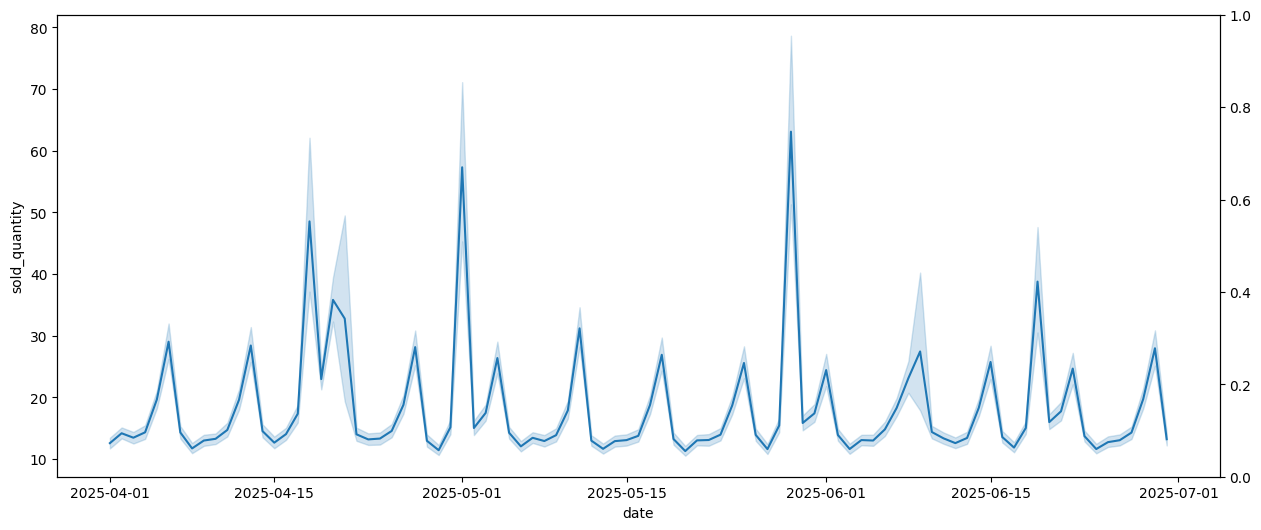

In [36]:
# plotting sold_quantity per date and is_holiday

# plot
fig, ax = plt.subplots(1,1, figsize=(15,6))

sns.lineplot(sales, x='date', y='sold_quantity', label='sold_quantity', ax=ax, legend=False)

# 2nd y-axis on the right
ax2 = ax.twinx()
sns.scatterplot(holidays, x='date', y='is_holiday', color='r',label='holiday', ax=ax2, legend=False)

# getting labels of both axes
lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
plt.legend(lines + lines2, labels + labels2, loc='upper left')

# all dates for grid
all_dates = pd.date_range(start=min(holidays['date'].min(), sales['date'].min()),
                          end=max(holidays['date'].max(), sales['date'].max()),
                          freq='D')

ax.set_xticks(all_dates[::15])  
ax.grid(True, which='both', axis='x', alpha=0.6) 


# additional lines per day
for d in all_dates:
    ax.axvline(d, color='gray', linestyle='-', alpha=0.2, zorder=0)

#ax.grid(True, alpha=0.6)
plt.title('Sales per date per holidays')
plt.xticks(rotation=65)
ax2.set_yticks([])
ax2.set_ylabel('')
plt.show()

In [ ]:
# prepare for merging

holidays = holidays.drop(columns=['day_of_month', 'week'], errors='ignore')
holidays.head()

## __Data: Weather__

In [37]:
# data loading
weather = pd.read_parquet('20260218_144523_weather.parquet', engine='pyarrow')
display(weather.head())

,date,time,zipcode,temperature,wind_speed,wind_degree,wind_dir,weather_code,weather_description,precip,humidity,visibility,pressure,cloudcover,heatindex,dewpoint,windchill,windgust,feelslike,chanceofrain,chanceofremdry,chanceofwindy,chanceofovercast,chanceofsunshine,chanceoffrost,chanceofhightemp,chanceoffog,chanceofsnow,chanceofthunder,uv_index
0,2025-04-01,20:00,41812,10.0,16.0,79.0,ENE,113,Clear,0.0,56.0,10.0,1024.0,0.0,10.0,1.0,7.0,32.0,7.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,2025-04-01,21:00,41812,9.0,16.0,75.0,ENE,113,Clear,0.0,60.0,10.0,1024.0,1.0,9.0,1.0,6.0,32.0,6.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,2025-04-01,22:00,41812,9.0,18.0,71.0,ENE,113,Clear,0.0,62.0,10.0,1025.0,0.0,9.0,2.0,6.0,33.0,6.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,2025-04-01,23:00,41812,8.0,20.0,70.0,ENE,113,Clear,0.0,63.0,10.0,1025.0,2.0,8.0,2.0,5.0,35.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,2025-04-01,00:00,41812,6.0,10.0,52.0,NE,113,Clear,0.0,74.0,10.0,1028.0,0.0,6.0,2.0,4.0,21.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


### Overview

In [38]:
# shape
print('Shape holidays:', weather.shape, end='\n\n')

# info
print(weather.info())

# decription numeric and categorical
display(weather.describe())
display(weather.describe(include='str'))

Shape holidays: (78624, 30)

<class 'pandas.DataFrame'>
RangeIndex: 78624 entries, 0 to 78623
Data columns (total 30 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   date                 78624 non-null  datetime64[ns]
 1   time                 78624 non-null  str           
 2   zipcode              78624 non-null  str           
 3   temperature          78624 non-null  float64       
 4   wind_speed           78624 non-null  float64       
 5   wind_degree          78624 non-null  float64       
 6   wind_dir             78624 non-null  str           
 7   weather_code         78624 non-null  int64         
 8   weather_description  78624 non-null  str           
 9   precip               78624 non-null  float64       
 10  humidity             78624 non-null  float64       
 11  visibility           78624 non-null  float64       
 12  pressure             78624 non-null  float64       
 13  cloudcover   

,date,temperature,wind_speed,wind_degree,weather_code,precip,humidity,visibility,pressure,cloudcover,heatindex,dewpoint,windchill,windgust,feelslike,chanceofrain,chanceofremdry,chanceofwindy,chanceofovercast,chanceofsunshine,chanceoffrost,chanceofhightemp,chanceoffog,chanceofsnow,chanceofthunder,uv_index
count,78624,78624.000000,78624.000000,78624.000000,78624.000000,78624.000000,78624.000000,78624.000000,78624.000000,78624.000000,78624.000000,78624.000000,78624.000000,78624.000000,78624.000000,78624.0,78624.0,78624.0,78624.0,78624.0,78624.0,78624.0,78624.0,78624.0,78624.0,78624.000000
mean,2025-05-16 00:00:00,13.819521,13.142577,177.389474,141.274267,0.059655,69.556853,9.577101,1018.022563,39.178139,13.974295,7.872265,12.926804,20.037635,12.998766,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.633916
min,2025-04-01 00:00:00,-2.000000,0.000000,0.000000,113.000000,0.000000,23.000000,0.000000,998.000000,0.000000,-2.000000,-11.000000,-6.000000,0.000000,-6.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.000000
25%,2025-04-23 00:00:00,10.000000,9.000000,87.000000,113.000000,0.000000,57.000000,10.000000,1015.000000,7.000000,10.000000,5.000000,8.000000,14.000000,8.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.000000
50%,2025-05-16 00:00:00,13.000000,12.000000,204.000000,116.000000,0.000000,71.000000,10.000000,1018.000000,26.000000,13.000000,8.000000,12.000000,19.000000,12.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.000000
75%,2025-06-08 00:00:00,17.000000,17.000000,257.000000,143.000000,0.000000,84.000000,10.000000,1022.000000,74.000000,17.000000,11.000000,17.000000,25.000000,17.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.000000
max,2025-06-30 00:00:00,32.000000,39.000000,360.000000,389.000000,8.500000,99.000000,10.000000,1029.000000,100.000000,33.000000,22.000000,32.000000,61.000000,33.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,8.000000
std,NaN,5.665801,6.522310,101.179081,57.894296,0.288629,16.739121,1.750297,5.612091,35.601236,5.907601,4.512992,6.374721,8.706802,6.507605,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.890117


,time,zipcode,wind_dir,weather_description
count,78624,78624,78624,78624
unique,24,36,16,25
top,20:00,41812,WSW,Clear
freq,3276,2184,9285,20955


### Data Structure

This table contains weather indicators observed in the given time span of Qtr 2, 2025

> **date**: The calendar date on which the weather observation was recorded. [datetime64, categorical]

> **time**: The time of day when the weather measurement was taken. [str, categorical]

> **zipcode**: The postal code representing the geographic area where the weather observation was recorded. [str, categorical]

> **temperature**: The measured air temperature at the given location and time, typically expressed in degrees Celsius. [float, quantitative]

> **wind_speed**: The speed of the wind at the time of observation. [float, quantitative]

> **wind_degree**: The wind direction expressed in degrees, indicating the direction from which the wind originates. [float, quantitative]

> **wind_dir**: The cardinal direction of the wind (e.g., N, NE, SW) describing where the wind is coming from. [str, categorical]

> **weather_code**: A numeric code representing the general weather condition according to a predefined weather classification scheme. [int, categorical]

> **weather_description**: A textual description of the observed weather conditions (e.g., cloudy, light rain). [str, categorical]

> **precip**: The amount of precipitation recorded during the observation period. [float, quantitative]

> **humidity**: The relative humidity in the air expressed as a percentage. [float, quantitative]

> **visibility**: The distance at which objects can be clearly seen in the atmosphere. [float, quantitative]

> **pressure**: The atmospheric pressure measured at the observation location. [float, quantitative]

> **cloudcover**: The proportion of the sky covered by clouds expressed as a percentage. [float, quantitative]

> **heatindex**: The perceived temperature combining air temperature and humidity to represent how hot it feels to humans. [float, quantitative]

> **dewpoint**: The temperature at which air becomes saturated and water vapor begins to condense into dew. [float, quantitative]

> **windchill**: The perceived decrease in air temperature felt by the body due to wind. [float, quantitative]

> **windgust**: The maximum short burst of wind speed recorded during the observation period. [float, quantitative]

> **feelslike**: The perceived outdoor temperature considering factors such as humidity and wind. [float, quantitative]

> **chanceofrain**: The probability that rain will occur during the forecast period, expressed as a percentage. [float, quantitative]

> **chanceofremdry**: The probability that no precipitation will occur during the forecast period. [float, quantitative]

> **chanceofwindy**: The probability that windy conditions will occur during the forecast period. [float, quantitative]

> **chanceofovercast**: The probability that the sky will be mostly or completely covered by clouds. [float, quantitative]

> **chanceofsunshine**: The probability that sunny conditions will occur during the forecast period. [float, quantitative]

> **chanceoffrost**: The probability that frost conditions may occur. [float, quantitative]

> **chanceofhightemp**: The probability that temperatures will reach unusually high levels. [float, quantitative]

> **chanceoffog**: The probability that foggy conditions will occur. [float, quantitative]

> **chanceofsnow**: The probability that snowfall will occur. [float, quantitative]

> **chanceofthunder**: The probability that thunderstorm activity will occur. [float, quantitative]

> **uv_index**: The ultraviolet radiation index indicating the strength of sunburn-causing UV radiation. [float, quantitative]

### Data Cleaning

In [39]:
# duplicates?
print('Duplicates weather:', weather.duplicated().sum())

# missing values?
print('Missing values:', weather.isna().sum().sum())


Duplicates weather: 0
Missing values: 0


### Investigating inconsistencies / issues / etc

In [ ]:
# first view issues

# investigating "chancesof..." columns, which seem to be always 0.

# boxplot
plt.figure(figsize=(15,5))
weather.boxplot()
plt.xticks(rotation=70)
plt.show()

In [42]:
# getting all "chances of..." columns
chancesof_cols = list(weather.columns[19:-1])

weather_chancesof = weather[chancesof_cols]

display(weather_chancesof.value_counts())
print('-> Only 0 values in chancesof cols.')
print('-'*30)
print('Conclusion: Those columns only have one constant value (0), i.e. they do not provide information for a model -> we delete them.')

weather_reduced = weather.drop(columns=chancesof_cols)
weather_reduced.head()

chanceofrain  chanceofremdry  chanceofwindy  chanceofovercast  chanceofsunshine  chanceoffrost  chanceofhightemp  chanceoffog  chanceofsnow  chanceofthunder
0.0           0.0             0.0            0.0               0.0               0.0            0.0               0.0          0.0           0.0                78624
Name: count, dtype: int64

-> Only 0 values in chancesof cols.
------------------------------
Conclusion: Those columns only have one constant value (0), i.e. they do not provide information for a model -> we delete them.


,date,time,zipcode,temperature,wind_speed,wind_degree,wind_dir,weather_code,weather_description,precip,humidity,visibility,pressure,cloudcover,heatindex,dewpoint,windchill,windgust,feelslike,uv_index
0,2025-04-01,20:00,41812,10.0,16.0,79.0,ENE,113,Clear,0.0,56.0,10.0,1024.0,0.0,10.0,1.0,7.0,32.0,7.0,1.0
1,2025-04-01,21:00,41812,9.0,16.0,75.0,ENE,113,Clear,0.0,60.0,10.0,1024.0,1.0,9.0,1.0,6.0,32.0,6.0,1.0
2,2025-04-01,22:00,41812,9.0,18.0,71.0,ENE,113,Clear,0.0,62.0,10.0,1025.0,0.0,9.0,2.0,6.0,33.0,6.0,1.0
3,2025-04-01,23:00,41812,8.0,20.0,70.0,ENE,113,Clear,0.0,63.0,10.0,1025.0,2.0,8.0,2.0,5.0,35.0,5.0,1.0
4,2025-04-01,00:00,41812,6.0,10.0,52.0,NE,113,Clear,0.0,74.0,10.0,1028.0,0.0,6.0,2.0,4.0,21.0,4.0,1.0


#### Functional dependencies / redundant information

In [43]:
# weather_code and weather_description 
# seem to have redundant information

weather_code_decr = weather_reduced.groupby(['weather_code'])['weather_description'].apply(lambda x: list(set(x)))
print('Represantation of weather_code vs weather_decription - redundant information:')
print(weather_code_decr)
print('Conclusion: wether_description can be deleted.')


Represantation of weather_code vs weather_decription - redundant information:
weather_code
113                           [Clear, Sunny]
116                          [Partly cloudy]
119                                 [Cloudy]
122                               [Overcast]
143                                   [Mist]
176                   [Patchy rain possible]
200            [Thundery outbreaks possible]
248                                    [Fog]
260                           [Freezing fog]
263                   [Patchy light drizzle]
266                          [Light drizzle]
293                      [Patchy light rain]
296                             [Light rain]
299                 [Moderate rain at times]
302                          [Moderate rain]
308                             [Heavy rain]
317                            [Light sleet]
326                             [Light snow]
353                      [Light rain shower]
356          [Moderate or heavy rain shower]
359      

Temperature and Heatindex seem to be almost equal variables:

Description & Boxplot:
        temperature     heatindex
count  78624.000000  78624.000000
mean      13.819521     13.974295
std        5.665801      5.907601
min       -2.000000     -2.000000
25%       10.000000     10.000000
50%       13.000000     13.000000
75%       17.000000     17.000000
max       32.000000     33.000000


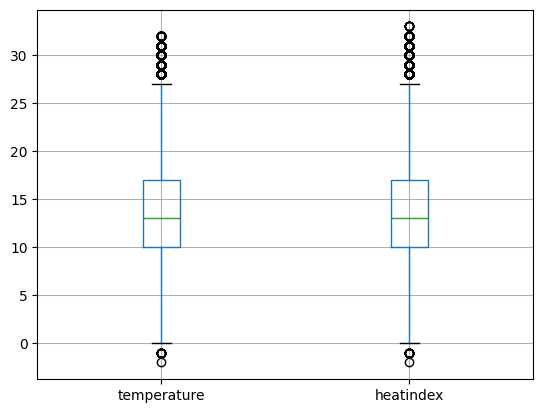

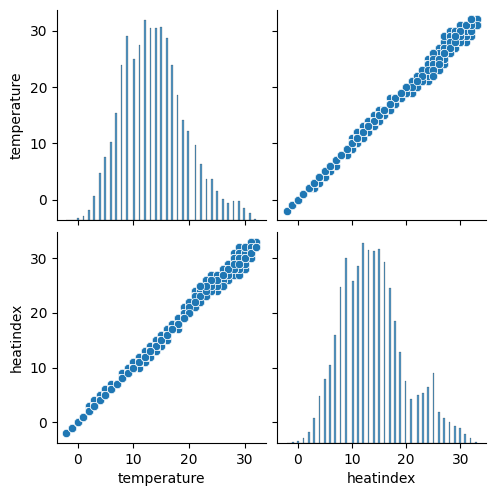

In [44]:
# temperature and headindex 
# seem to have quite the information.

print('Temperature and Heatindex seem to be almost equal variables:')

# compare description and boxplot
print('\nDescription & Boxplot:')
temp_heat = weather_reduced[['temperature', 'heatindex']]

print(temp_heat.describe())

# visual help
plt.figure()
temp_heat.boxplot()
sns.pairplot(data=temp_heat)
plt.show()

In [ ]:
# comparing temperature vs. heatindex
#print(temp_heat.value_counts())
temp_vs_heat = weather_reduced.groupby('temperature')['heatindex'].apply(lambda x: list(set(x)))
temp_vs_heat_mean = weather_reduced.groupby('temperature')['heatindex'].apply(lambda x: int(np.mean(list(set(x)))))

samples = temp_vs_heat.sample(30)
print('1) Variables temperature vs. heatindex:\n')
print(samples)

print('-'*30)

samples_rounded = temp_vs_heat_mean
print('\n2) Variables temperature vs. heatindex [ROUNDED MEAN] :\n')
print(samples_rounded)

print('\nAnalysis: As we can see, the heatindex seems to measure more precisely (1) but the mean of the heatindex values is almost identical to temperature (2)\
      .So we can conclude those variables provide the same information and one of them can be deleted.' )

## --> which one to delete? temperature or heatindex?



In [ ]:
# windchill and feelslike 
# seem to have redundant information, too

print('Windchell and Fellslike seem to be almost equal variables:\n')
print('Description & Boxplot:')
wind_feel = weather_reduced[['windchill', 'feelslike']]

print(wind_feel.describe())

plt.figure()
wind_feel.boxplot()
plt.show()

In [ ]:
wind_chill = weather_reduced.groupby('windchill')['feelslike'].apply(lambda x: set(x))
wind_chill_mean = weather_reduced.groupby('windchill')['feelslike'].apply(lambda x: round(np.mean(list(set(x)))))

print('Comparison windchil vs feelslike [ROUNDED MEAN]')
print(wind_chill_mean[:10])
print('\nAnalysis: We can see the same behaviour as in the former realtionships, so one (windchill or feelslike) can be deleted due to redundance.')

# linechart for visual comparison
xxx = range(len(wind_chill))
plt.plot(xxx, wind_chill_mean, label='windchill')
plt.plot(xxx, wind_chill_mean.index, c='m', label='feelslike')
plt.grid(True)
plt.title('windchill vs. feelslike')
plt.legend()
plt.show()

### Prepare for visualisation

In [ ]:
# deleting redundant columns (choice: Marcel -> können wir auch ändern)

delete_cols = ['windchill', 'heatindex', 'weather_code']

# new df
weather_reduced_2 = weather_reduced.drop(columns=delete_cols)

weather_reduced_2.head()


In [ ]:
# reducing weather df to day level, eleminating the hourly records

# what to groupby and what to aggragate (mean, etc..)
weather_per_day = weather_reduced_2.groupby(['date','zipcode']).agg({
 'temperature': 'mean',
 'wind_speed': 'mean',
 'wind_degree': 'mean',
 'wind_dir': lambda x: x.mode()[0],
 'weather_description': lambda y: y.mode()[0], # make sense?
 'precip': 'mean',
 'humidity': 'mean',
 'visibility': 'mean',
 'pressure': 'mean',
 'cloudcover': 'mean',
 'dewpoint': 'mean',
 'windgust': 'mean',
 'feelslike': 'mean',
 'uv_index': 'mean'
 }
).reset_index()


# new weather df
display(weather_per_day.head())
print('Shape:', weather_per_day.shape)


## __Creating one final dataframe for modeling__

### Merging

In [ ]:
# dataframes to merge

print('Sales:')
display(sales.head(2))
print(sales.shape)

print('Stores:')
display(stores.tail(2))
print(stores.shape)

print('Holiday:')
display(holidays.head(2))
print(holidays.shape)


print('weather_per_day:')
display(weather_per_day.head())
print(weather.shape)

In [ ]:
# mew main dataframe df based on sales
df = sales

# adding zipcode from stores
df['zipcode'] = df['store_id'].map(stores.set_index('store_id')['zipcode'])
print(df.shape)

# adding holiday_name and holiday_type from holiday to df
holidays_merge_cols = holidays[['zipcode', 'date', 'holiday_type']] #'holiday_name',
df = df.merge(holidays_merge_cols, on=['date', 'zipcode'], how='left').fillna('-')

display(df.head())
print(df.shape)
print(df.isna().sum())

In [ ]:
##!!  ---- to be discussed -----.

# adding weather data

# df = df.merge(weather_per_day, on='date', how='left')  #---> memory error

# before adding all weather columns to the new df, we should discuss whicht we really need...dewpoint?

#df.head()

weather_so_far = weather_per_day[['date', 'zipcode', 'temperature', 'weather_description', 'precip', 'cloudcover', 'feelslike']].head()

df = df.merge(weather_so_far, on=['date', 'zipcode'], how='left')

print(df.shape)
display(df.head())
print(df.shape)


In [ ]:
##!! work in progress....

dupped = df.duplicated()#.sum()

print('Dupes:', dupped.sum())
df[dupped].tail()

### Preparing for modeling (pre-processing)

... to be continued

# __Visualization__


#### __Sales per Week / Weekday__

In [45]:
# sales per week and weekday

sales_per_week = sales.groupby('week')['sold_quantity'].sum()[:-1] # last week incomplete
#print('Sales per week:')
#print(sales_per_week)

qty_mean = sales_per_week.mean()
#print('Mean sold qty')
#print(qty_mean)

## -- plots

fig, ax = plt.subplots(1,2, figsize=(15,5))

ax[0].bar(sales_per_week.index, sales_per_week, color='m')
ax[0].set_xticks(sales_per_week.index)
ax[0].yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{int(x/1000)}K'))
ax[0].axhline(qty_mean, color='g', alpha=0.6, lw=2, ls='--', label=f'Average: {qty_mean/1e3:,.1f}K')

ax[0].set_xlabel('Week')
#ax[0].set_ylabel('QTY')

ax[0].set_title('Overall Sales per Week')


# ---------------------

sales_per_weekday = sales.groupby('day_of_week')['sold_quantity'].sum()
#print('Sales per day_of_week:')
#print(sales_per_weekday)

qty_mean = sales_per_weekday.mean()
#print('Mean sold qty')
#print(qty_mean)

bars = ax[1].bar(sales_per_weekday.index, sales_per_weekday, color='m')

ax[1].set_xticks(sales_per_weekday.index, ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])
ax[1].yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x/1e6}M'))

ax[1].axhline(qty_mean, color='g', alpha=0.5, lw=2, ls='--', label=f'Average: {qty_mean/1e6:,.0f}M')

ax[1].set_xlabel('Day of Week', fontsize=8)
#ax[1].set_ylabel('QTY', fontsize=8)
ax[1].set_yticks([])

ax[1].set_title('Overall Sales per Weekday')

# adding bar labels on top
bar_labels = [f'{v/1e6:,.1f}M' for v in sales_per_weekday]
ax[1].bar_label(bars, labels=bar_labels , padding=3)


# ------ for all

for a in ax:
    a.grid(axis='y', alpha=.6)
    a.spines[['top', 'left', 'right']].set_visible(False)
    a.legend(loc='center', framealpha=0.95)

fig.suptitle('Overall Sales per Time  - (Qtr 2, 2025)', fontsize=16)
plt.show()

KeyError: 'week'

#### __Sales per Category / Item__

In [ ]:
# Top 10 Category ---

cat_sales = sales.groupby('category_name')['sold_quantity'].sum().sort_values(ascending=False)

#print('Overall sold_quantity by category:')
#display(cat_sales)

top_10_cat = cat_sales.head(10)

top_10_cat = pd.DataFrame(top_10_cat).sort_values('sold_quantity', ascending=True)

#display(top_10_cat)

## ----------------------------------------------

# Top 10 Sold Items ---

item_sales = sales.groupby('item_id')['sold_quantity'].sum().sort_values(ascending=False)

top_10_item = item_sales.sort_values(ascending=False).head(10)

top_10_item = pd.DataFrame(top_10_item).sort_values('sold_quantity')



In [ ]:
# Top 10 Category: plot


fig, ax = plt.subplots(1,2, figsize=(15,6))


# top 10 category
bar_cat = ax[0].barh( top_10_cat.index.astype(str), top_10_cat.sold_quantity, color='m')

bar_labels = [f'{v/1e3:.0f}K' if v < 1e6 else f'{v/1e6:.2f}M' for v in top_10_cat.sold_quantity]

ax[0].bar_label(bar_cat, labels=bar_labels, padding=2)

ax[0].set_ylabel('Product Category', fontsize=12)
ax[0].set_title('Product Category - Top 10')


# ----------------

# Top 10 Sold Items: plot


# top 10 category items
bars_item = ax[1].barh(top_10_item.index.astype(str), top_10_item.sold_quantity,  color='m')

bar_labels = [f'{v/1e3:.0f}K' if v < 1e6 else f'{v/1e6:.2f}M' for v in top_10_item.sold_quantity]

ax[1].bar_label(bars_item, labels=bar_labels, padding=2)

ax[1].set_ylabel('Category Item Id.', fontsize=12)
ax[1].set_title('Sold Items - Top 10')

# for all plots-----

for a in ax:
   #a.grid(axis='x', alpha=0.6)
    a.spines[['top', 'bottom', 'right']].set_visible(False)
    a.set_xticks([])

fig.suptitle('Overall Sales per Category and Category Item (Qtr 2, 2025)', fontsize=18)

plt.show()


#### __Sales per Store__

In [ ]:
# Top 10 stores

top_10_stores = sales.groupby('store_id').agg(sold_qty_sum=('sold_quantity', 'sum'), sold_qty_std=('sold_quantity', 'std')).sort_values('sold_qty_sum', ascending=False)
top_10_stores = top_10_stores.head(10).sort_values('sold_qty_sum', ascending=True)
top_10_stores


In [ ]:
# op 10 stores: plot

fig, ax = plt.subplots(1,1, figsize=(8,6))

# top 10 category items
bars = ax.barh(top_10_stores.index.astype(str), top_10_stores.sold_qty_sum,  color='m')
bar_labels = [f'{v/1e3:.0f}K' if v < 1e6 else f'{v/1e6:.2f}M' for v in top_10_stores.sold_qty_sum]
ax.bar_label(bars, labels=bar_labels, padding=2)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
#ax.set_xlim(1.3e5, 3.6e5)

ax.set_xlabel('Sold Unites')
ax.set_ylabel('Store Id.', fontsize=8)
ax.set_title('Stores - Top 10 (Qtr2 2025)')

ax.grid(axis='x', alpha=0.6, )

plt.show()

# __Further investigations__

In [ ]:
### check item_id in category per store
### ------------------- category_name -> item_id
### -----------
### -----------
### -----------

# c = sales.category_name == 'Brotwaage'
# sales[c]

# pd.set_option("display.max_colwidth", None)

# category_list = sales.category_name.unique()
# for i, v in enumerate(category_list):
#     print(f'{i} {v}')

# sales_grp = pd.DataFrame(sales.groupby(['store_id', 'category_name'])['item_id'].apply(lambda x: sorted(x.unique())))
# cond = sales_grp.index.get_level_values('category_name') == category_list[11]

# sales_grp[cond]


In [26]:
# investigating item_id appearing in more than one category_name

# group to get every category_name for each item_id, count normalized values to see distributions of item_id in category_name
sales_item_id = pd.DataFrame(sales.groupby(['store_id', 'item_id'])['category_name']
                             .apply(lambda x: pd.Series(x)\
                             .value_counts(normalize=True)))

# count every occurences of category_names
sizes = sales_item_id.groupby(['store_id', 'item_id'])['category_name'].transform('size')

# filter non-unique item_id appearing in more than one category_name
item_id_dups = sales_item_id[sizes > 1]

display(item_id_dups.head(30))


category_name
store_id item_id                                 
0        52      Brötchen                0.838095
                 Brot                    0.161905
         58      Brötchen                0.880000
                 Brot                    0.120000
         59      Brötchen                0.553459
                 Brot                    0.446541
         84      Brot                    0.873239
                 Brötchen                0.126761
         170     Angebot Brötchen        0.833333
                 Brötchen                0.166667
         248     Brötchen                0.576000
                 Kuchen                  0.424000
         250     Brötchen                0.887500
                 Konditorei              0.112500
         256     Brötchen                0.972603
                 Konditorei              0.027397
         487     Snack Belag             0.538462
                 Snack                   0.461538
         497     Snack                   0.931034
                 Snack Belag             0.068966
1        170     Angebot Brötchen        0.909091
                 Brötchen                0.090909
         248     Brötchen                0.529412
                 Kuchen                  0.470588
         487     Snack Belag             0.545455
                 Snack                   0.454545
         497     Snack                   0.981481
                 Snack Belag             0.018519
         630     Snack Belag             0.933333
                 Heißgetränke            0.066667

In [13]:
display(item_id_dups.head(30))

category_name
store_id item_id                                 
0        52      Brötchen                0.838095
                 Brot                    0.161905
         58      Brötchen                0.880000
                 Brot                    0.120000
         59      Brötchen                0.553459
                 Brot                    0.446541
         84      Brot                    0.873239
                 Brötchen                0.126761
         170     Angebot Brötchen        0.833333
                 Brötchen                0.166667
         248     Brötchen                0.576000
                 Kuchen                  0.424000
         250     Brötchen                0.887500
                 Konditorei              0.112500
         256     Brötchen                0.972603
                 Konditorei              0.027397
         487     Snack Belag             0.538462
                 Snack                   0.461538
         497     Snack                   0.931034
                 Snack Belag             0.068966
1        170     Angebot Brötchen        0.909091
                 Brötchen                0.090909
         248     Brötchen                0.529412
                 Kuchen                  0.470588
         487     Snack Belag             0.545455
                 Snack                   0.454545
         497     Snack                   0.981481
                 Snack Belag             0.018519
         630     Snack Belag             0.933333
                 Heißgetränke            0.066667

In [14]:
# flatten multiindexed df
item_id_dubs_flat = item_id_dups.reset_index(names=['store_id', 'item_id', 'category']).rename(columns={'category_name': 'distribution'})
display(item_id_dubs_flat.tail(10))



,store_id,item_id,category,distribution
218,51,135,Printen/Kekse,0.625000
219,51,135,Kuchen,0.375000
220,54,135,Printen/Kekse,0.571429
221,54,135,Kuchen,0.428571
222,57,135,Printen/Kekse,0.500000
223,57,135,Kuchen,0.500000
224,58,135,Kuchen,0.500000
225,58,135,Printen/Kekse,0.500000
226,59,135,Printen/Kekse,0.500000
227,59,135,Kuchen,0.500000


In [ ]:
# viz

# .....to be continued
